#Método de Newton-Raphson

In [12]:
import math

#metodo de newton-raphson
def newton(f,df,x0,eps,itmax):
    L=range(1,itmax+1)
    iteracao=0
    a=x0
    print('k = ',0,'  raiz = ',x0, '  |f(raiz)| = ',math.fabs(f(x0)),'  |df(raiz)| = ', math.fabs(df(x0)))

    for i in L:
        raiz=a
        if df(raiz) != 0:
            #calculo da proxima raiz
            raiz=raiz-f(raiz)/df(raiz)
            erro= math.fabs(raiz-a)
            a=raiz
            iteracao=i
        else:
            #erro de derivacao = 0
            iteracao = itmax+1
            break

        print('k = ',i,'  raiz = ',raiz, '  |f(raiz)| = ',math.fabs(f(raiz)),'  |df(raiz)| = ',math.fabs(df(raiz)), ' erro = ',erro)

        if abs(erro) <= eps:
            #criterio de parada atingido
            break

    #codigos de erro
    if iteracao > itmax:
        iteracao = 0.25
    elif iteracao == itmax:
        iteracao = 0.75

    return [raiz, erro, iteracao]

#declarando a funcao de vpl e sua derivada
f= lambda x: -600 + 200 * ((1.2**x - 1) / (0.2 * 1.2**x))
df= lambda x: 1000 * math.log(1.2) * 1.2**(-x)

L=newton(f,df,0.5,0.01,100)
print (f'\nRaiz Encontrada: {L[0]:.5f}\nErro Final: {L[1]:.5f}\nIterações: {L[2]}')

k =  0   raiz =  0.5   |f(raiz)| =  512.870929175277   |df(raiz)| =  166.43604895918034
k =  1   raiz =  3.581489451249004   |f(raiz)| =  120.4909738453506   |df(raiz)| =  94.89672464868582  erro =  3.081489451249004
k =  2   raiz =  4.8511958008771545   |f(raiz)| =  12.929843575382506   |df(raiz)| =  75.28601192734789  erro =  1.2697063496281507
k =  3   raiz =  5.022938774696248   |f(raiz)| =  0.20033606775712087   |df(raiz)| =  72.96514830133728  erro =  0.17174297381909387
k =  4   raiz =  5.025684415216703   |f(raiz)| =  5.013469535697368e-05   |df(raiz)| =  72.92863185821754  erro =  0.002745640520454451

Raiz Encontrada: 5.02568
Erro Final: 0.00275
Iterações: 4


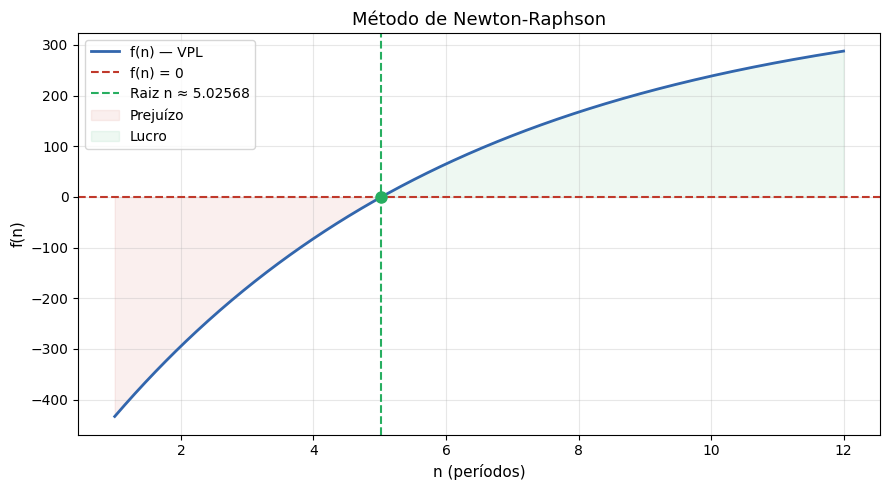

In [14]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('default')
n_vals = np.linspace(1, 12, 500)
f_vals = [f(n) for n in n_vals]
raiz = L[0]

plt.figure(figsize=(9, 5))
plt.plot(n_vals, f_vals, color="#3266ad", linewidth=2, label="f(n) — VPL")
plt.axhline(0, color="#c0392b", linewidth=1.5, linestyle="--", label="f(n) = 0")
plt.axvline(raiz, color="#27ae60", linewidth=1.5, linestyle="--", label=f"Raiz n ≈ {raiz:.5f}")
plt.plot(raiz, f(raiz), "o", color="#27ae60", markersize=8, zorder=5)
plt.fill_between(n_vals, f_vals, 0, where=[v < 0 for v in f_vals], alpha=0.08, color="#c0392b", label="Prejuízo")
plt.fill_between(n_vals, f_vals, 0, where=[v > 0 for v in f_vals], alpha=0.08, color="#27ae60", label="Lucro")
plt.xlabel("n (períodos)", fontsize=11)
plt.ylabel("f(n)", fontsize=11)
plt.title("Método de Newton-Raphson", fontsize=13)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()